<a href="https://colab.research.google.com/github/Sayandt-web/A-Review-of-Image-Methods-Based-on-Deep-Learning-/blob/main/(GAN%2C_CNN%2C_Transformer%2C_Diffusion_methods).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A Review of Image Methods Based on Deep Learning (Zishan Xu)

https://www.mdpi.com/2076-3417/13/20/11189

In [ ]:
!pip install pywavelets opencv-python matplotlib torch torchvision

In [ ]:
import cv2
import pywt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader

In [ ]:
def dwt_decompose(image):

    coeffs = pywt.dwt2(image, 'haar')

    LL, (LH, HL, HH) = coeffs

    return LL, LH, HL, HH

In [ ]:
def show_dwt(image):

    LL, LH, HL, HH = dwt_decompose(image)

    plt.figure(figsize=(10,8))

    plt.subplot(2,2,1)
    plt.imshow(LL,cmap='gray')
    plt.title("LL")

    plt.subplot(2,2,2)
    plt.imshow(LH,cmap='gray')
    plt.title("LH")

    plt.subplot(2,2,3)
    plt.imshow(HL,cmap='gray')
    plt.title("HL")

    plt.subplot(2,2,4)
    plt.imshow(HH,cmap='gray')
    plt.title("HH")

    plt.show()

In [ ]:
class NoiseDetectorCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(4,32,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(128,128,3,padding=1),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(

            nn.Conv2d(128,64,1),
            nn.ReLU(),

            nn.Conv2d(64,1,1),
            nn.Sigmoid()
        )

    def forward(self,x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [ ]:
class RestorationCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(1,64,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(64,64,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(

            nn.Conv2d(128,64,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(64,32,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(32,1,3,padding=1),
            nn.Sigmoid()
        )

    def forward(self,x):

        x = self.encoder(x)
        x = self.decoder(x)

        return x

In [ ]:
class AncientImageRestoration(nn.Module):

    def __init__(self):

        super().__init__()

        self.noise_detector = NoiseDetectorCNN()
        self.restorer = RestorationCNN()

    def forward(self,dwt_features,image):

        noise_map = self.noise_detector(dwt_features)

        restored = self.restorer(image)

        return restored, noise_map

In [ ]:
def prepare_dwt_tensor(gray_img):

    LL,LH,HL,HH = dwt_decompose(gray_img)

    features = np.stack([LL,LH,HL,HH],axis=0)

    tensor = torch.tensor(
        features,
        dtype=torch.float32
    ).unsqueeze(0)

    return tensor

In [ ]:
import cv2

img = cv2.imread('/content/noisy_test_image_256x256.png', 0)
img = cv2.resize(img, (256,256))
img_norm = img / 255.0

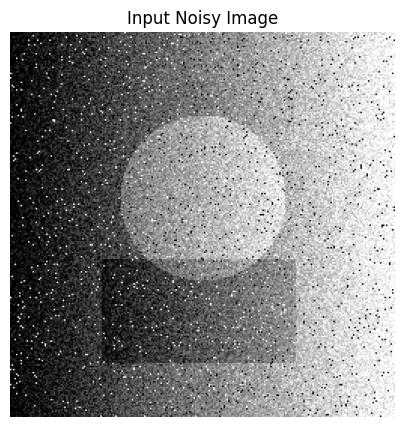

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/noisy_test_image_256x256.png', 0)
img = cv2.resize(img, (256,256))

plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')
plt.title("Input Noisy Image")
plt.axis('off')
plt.show()

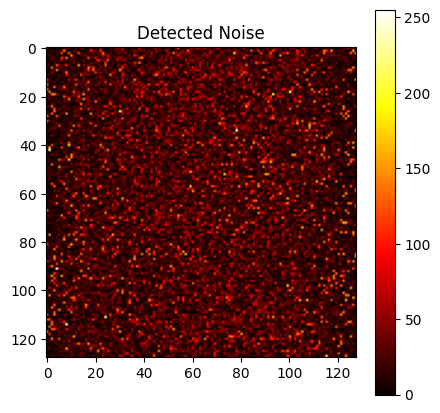

In [ ]:
!pip install PyWavelets

import pywt

# Perform DWT
coeffs2 = pywt.dwt2(img, 'haar')
LL, (LH, HL, HH) = coeffs2

# Noise Map
noise_map = np.abs(HH)

# Normalize for display
noise_map = cv2.normalize(
    noise_map,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

plt.figure(figsize=(5,5))
plt.imshow(noise_map, cmap='hot')
plt.title("Detected Noise")
plt.colorbar()
plt.show()

In [ ]:
noise_map = np.abs(HH)

noise_map = cv2.normalize(
    noise_map,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

X = noise_map.reshape(1, 128, 128, 1)
X = X.astype('float32') / 255.0

print(X.shape)

(1, 128, 128, 1)


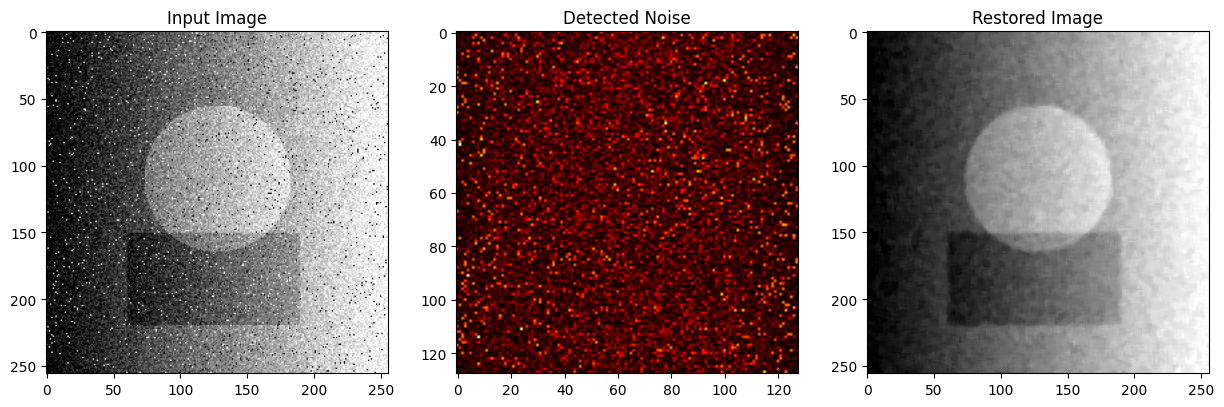

In [ ]:
restored = cv2.medianBlur(img, 5)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Input Image")

plt.subplot(1,3,2)
plt.imshow(noise_map, cmap='hot')
plt.title("Detected Noise")

plt.subplot(1,3,3)
plt.imshow(restored, cmap='gray')
plt.title("Restored Image")

plt.show()

In [ ]:
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

psnr = peak_signal_noise_ratio(img, restored)
ssim = structural_similarity(img, restored)

print("PSNR:", psnr)
print("SSIM:", ssim)

PSNR: 31.9227629100766
SSIM: 0.9547960126028978
